# K-Means Clustering 

This notebook implements **K-Means Clustering**as taught in **Stanford's CS229: Machine Learning (Autumn 2018, Lecture 13 - Expectation-Maximization Algorithms)** by **Andrew Ng**.

It includes:

- Feature normalization using **Z-score**
- **Random** and **K-Means++** centroid initialization
- Lloyd's K-Means optimization algorithm
- Multiple random restarts (**n_init**) to improve convergence
- Convergence based on the K-Means objective function (Inertia)
- Decision boundary visualization using Voronoi regions  
- Validation against **scikit-learn's KMeans**
- Evaluation using **Inertia**, **Adjusted Rand Index (ARI)**, and **Normalized Mutual Information (NMI)**
  
> 📘 This is part of a broader `ml-from-scratch` project implementing foundational machine learning algorithms using only **NumPy** and **pandas** for educational and intuitive understanding.
  


In [3]:
import pickle
import matplotlib
import numpy as np
import pandas as pd
from numpy import ndarray, float64
import matplotlib.pyplot as plt

In [4]:
class K_means:
    def __init__(self):
        self.k: int = None
        self.x_mean: ndarray = None
        self.prev_x_mean: ndarray = None
        self.x_std: ndarray = None
        self.prev_x_std: ndarray = None
        self.categorie: ndarray = None
        self.labels: ndarray = None
        self.inertia: float64 = None
    @staticmethod
    def J(x, mue, categories):
        return np.sum((x - mue[categories]) ** 2)

    def initialize(self, x_train, k,Kplus):
        self.k=k
        indices = np.random.choice(x_train.shape[0], size=k, replace=False)
        if Kplus == False: 
            self.x_mean = x_train[indices]
        else:
            n_samples = x_train.shape[0]
            first_idx = np.random.choice(n_samples)
            chosen = {first_idx}
            centroids =[x_train[first_idx]]

            for _ in range(1, k):
                distance = np.sum((x_train[:, np.newaxis] - np.array(centroids)) ** 2, axis = 2)

                nearest_distance = np.min(distance, axis =1)
                for idx in chosen:
                    nearest_distance[idx] = 0

                probabilities = nearest_distance / nearest_distance.sum()
                next_idx = np.random.choice(n_samples, p = probabilities)
                chosen.add(next_idx)
                centroids.append(x_train[next_idx])
                self.x_mean=np.array(centroids)

        self.categorie = np.arange(k)
        self.labels = np.zeros(x_train.shape[0], dtype=int)

    def train(self,x_train: ndarray, k: int, max_iters: int = 10,Kplus=True):
        self.initialize(x_train, k, Kplus)
        error = []
        self.prev_x_mean = np.zeros(self.x_mean.shape)
        for _ in range(max_iters):
            distance = np.square(np.linalg.norm(x_train[:, np.newaxis] - self.x_mean, axis = 2))
            self.labels = np.argmin(distance, axis = 1)
            for j in range(k):
                points = x_train[self.labels == j]
                if len(points) > 0:
                    self.x_mean[j] = np.mean(points, axis=0)
            error.append(K_means.J(x_train, self.x_mean,self.labels))
            if np.allclose(self.x_mean,self.prev_x_mean,atol=1e-6):
                return self.x_mean, error
            self.prev_x_mean = self.x_mean.copy()
        return self.x_mean, error

    def fit(self, x_train, k, n_init = 10, max_iters=100, kplus= True):
        best_cost = np.inf
        best_centroids = None
        best_lqabels = None
        best_error = None
        if kplus == True:
            print("Intiilize using K++") 
        for _ in range(n_init):

            centroids, error = self.train(
                x_train,
                k,
                max_iters,
                kplus
            ) 

            cost = self.J(x_train, self.x_mean, self.labels)

            if cost < best_cost:
                best_cost = cost
                best_centroids = self.x_mean.copy()
                best_labels = self.labels.copy()
                best_error = error.copy()

        self.x_mean = best_centroids
        self.labels = best_labels
        self.inertia = best_cost
        plt.plot(best_error)
        plt.xlabel("Iteration")
        plt.ylabel("Cost (J)")
        plt.title("K-Means Convergence")
        plt.grid(True)
        plt.show()
        return best_centroids, best_error
    
    def save(self, path):
        state = {
            "k": self.k,
            "centroids": self.x_mean,
            "labels": self.labels
        }

        with open(path, "wb") as f:
            pickle.dump(state, f)

    @staticmethod
    def load(path):
        with open(path, "rb") as f:
            state = pickle.load(f)

        model = K_means()

        model.k = state["k"]
        model.x_mean = state["centroids"]
        model.labels = state["labels"]

        return model
    
    def predict(self, X):
        distance = np.sum(
            (X[:, np.newaxis] - self.x_mean) ** 2,
        axis=2
        )
        return np.argmin(distance, axis=1)

In [5]:
def plot_decision_boundary(X, centroids, labels, resolution=300):

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    distances = np.sum(
        (grid[:, np.newaxis] - centroids) ** 2,
        axis=2
    )
    k = centroids.shape[0]
    grid_labels = np.argmin(distances, axis=1).reshape(xx.shape)
    cmap =  matplotlib.colormaps.get_cmap("tab20").resampled(k)
    plt.figure(figsize=(8,6))
    plt.contourf(
        xx,
        yy,
        grid_labels,
        levels=np.arange(k + 1) - 0.5,
        alpha=0.25,
        cmap=cmap
    )
    plt.contour(
        xx,
        yy,
        grid_labels,
        levels=np.arange(k + 1) - 0.5,
        colors="gray",      
        linewidths=1.0
        )
    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap=cmap,
        edgecolors="k",
        s=40
    )
    plt.scatter(
        centroids[:,0],
        centroids[:,1],
        marker="^",
        s=40,
        c="red",
        label="Centroids"
    )
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("K-Means Decision Boundary")
    plt.legend()
    plt.show()

In [ ]:
data = pd.read_csv(
    "./data/Aggregation.txt",
    sep=r"\s+",
    header=None
)

In [109]:
X = data.iloc[:, :2].values
X_mean=X.mean(axis=0)
X_std=X.std(axis=0)
X_std[X_std==0] = 1
X_normalize = (X - X_mean) / X_std

In [110]:
model=K_means()

Intiilize using K++


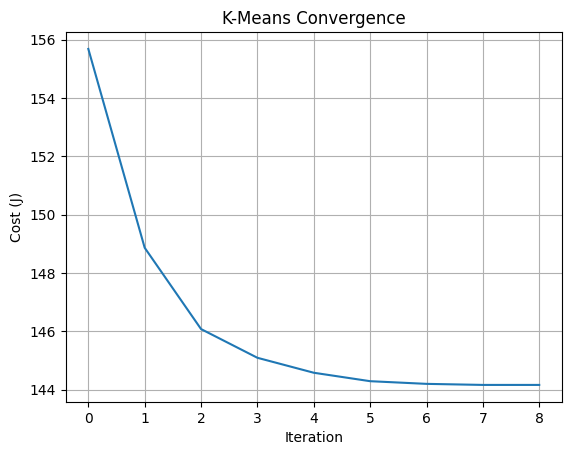

In [111]:
centroids, error = model.fit(X_normalize,7,1000, 1000)

In [112]:
model.inertia

np.float64(144.15989617580058)

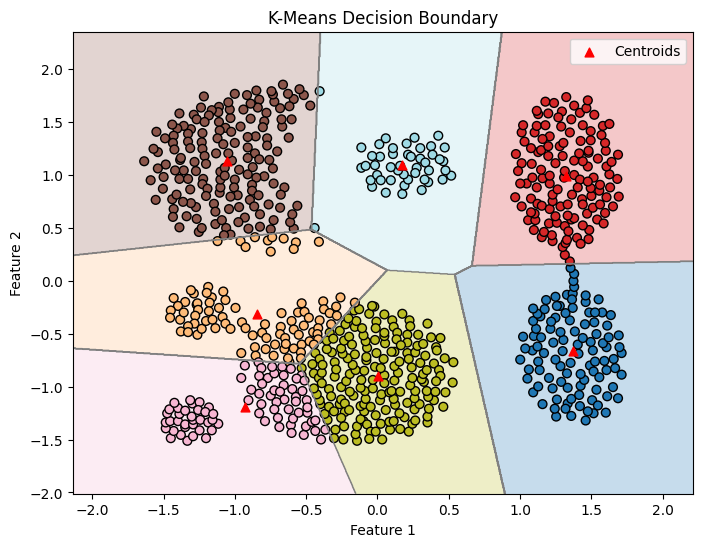

In [113]:
plot_decision_boundary(X_normalize, centroids, model.labels, 1000)

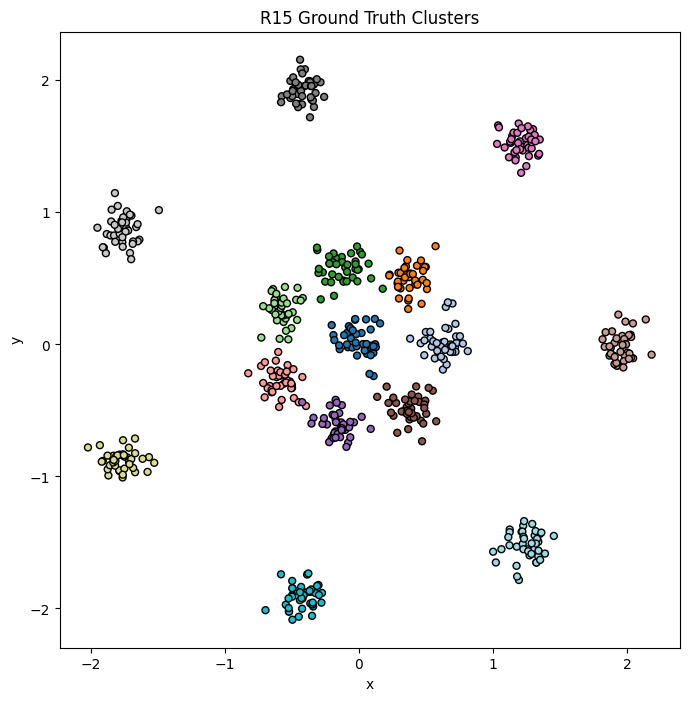

In [6]:
data = pd.read_csv("./data/R15.csv")

X = data[["x", "y"]].values
x_mean = X.mean(axis=0)
x_std = X.std(axis=0)
x_std[x_std==0] = 1
x_norm = (X - x_mean)/ x_std
y = data["class"].values

plt.figure(figsize=(8, 8))

plt.scatter(
    x_norm[:, 0],
    x_norm[:, 1],
    c=y,
    cmap="tab20",      
    s=25,
    edgecolors="k"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("R15 Ground Truth Clusters")

plt.show()

Intiilize using K++


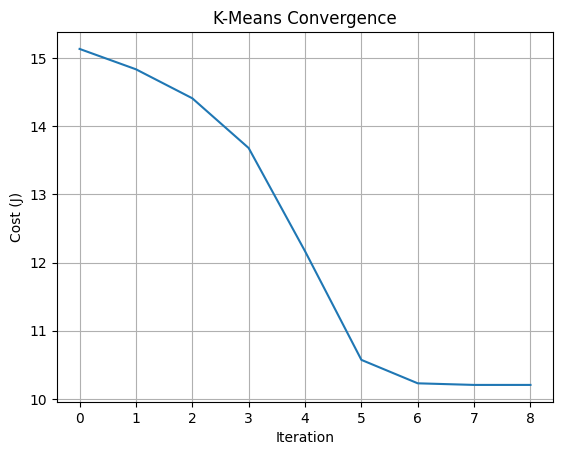

In [7]:
Model = K_means()
centroids, errors = Model.fit(x_norm, 15, 1000, 1000, True)

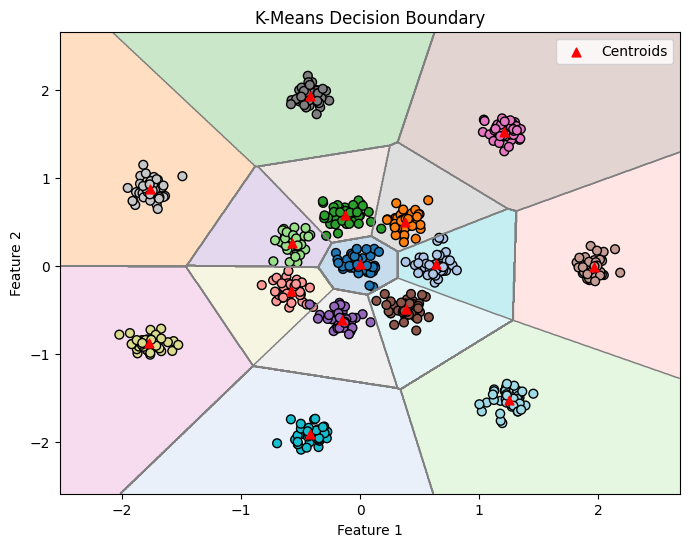

In [8]:
plot_decision_boundary(x_norm, centroids, y, 1000)

In [9]:
Model.inertia

np.float64(10.204808867138706)

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

In [12]:
sk_model = KMeans(
    n_clusters=15,
    init="k-means++",
    n_init=1000,
    max_iter=1000,
    tol=0,
    algorithm="lloyd",
    random_state=42
)

sk_labels = sk_model.fit_predict(x_norm)

print("=" * 40)
print("Benchmark against scikit-learn")
print("=" * 40)

print(f"Custom Inertia      : {Model.inertia:.12f}")
print(f"scikit-learn Inertia: {sk_model.inertia_:.12f}")
print(f"Difference          : {abs(Model.inertia - sk_model.inertia_):.12e}")

print("\nObjective verification")
print("----------------------")

print(
    "Custom J on sklearn solution:",
    K_means.J(
        x_norm,
        sk_model.cluster_centers_,
        sk_model.labels_
    )
)

print(
    "sklearn inertia:",
    sk_model.inertia_
)


if "y" in locals():
    print("\nClustering Metrics")
    print("------------------")

    print(
        "Custom ARI:",
        adjusted_rand_score(y, Model.labels)
    )

    print(
        "Custom NMI:",
        normalized_mutual_info_score(y, Model.labels)
    )

    print(
        "Sklearn ARI:",
        adjusted_rand_score(y, sk_labels)
    )

    print(
        "Sklearn NMI:",
        normalized_mutual_info_score(y, sk_labels)
    )

Benchmark against scikit-learn
Custom Inertia      : 10.204808867139
scikit-learn Inertia: 10.204808867139
Difference          : 1.776356839400e-15

Objective verification
----------------------
Custom J on sklearn solution: 10.204808867138706
sklearn inertia: 10.204808867138704

Clustering Metrics
------------------
Custom ARI: 0.9927781994136302
Custom NMI: 0.9942285075104654
Sklearn ARI: 0.9927781994136302
Sklearn NMI: 0.9942285075104654


## Results

The implementation was validated against benchmark datasets and **scikit-learn**.

### Aggregation Dataset

- Inertia identical to **scikit-learn's KMeans**.

### R15 Dataset

- Inertia: **10.204808867138706**
- Adjusted Rand Index (ARI): **0.9928**
- Normalized Mutual Information (NMI): **0.9942**

### Benchmark against scikit-learn

| Metric | Custom K-Means | scikit-learn |
|--------|---------------:|-------------:|
| Inertia | **10.204808867139** | **10.204808867139** |
| Objective Function (J) | **10.204808867139** | **10.204808867139** |
| Adjusted Rand Index (ARI) | **0.9928** | **0.9928** |
| Normalized Mutual Information (NMI) | **0.9942** | **0.9942** |

The custom implementation reproduces the same objective value and clustering performance as **scikit-learn's KMeans**, validating the correctness of the implementation.